In [ ]:
import glob
import os
import time
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn.functional as F
from torchgen import model
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import interp1d
from tqdm import tqdm

In [22]:
df = pd.read_csv("../../data/input_labels/paired_simulation_labels_combined.csv")

In [23]:
# ==========================================
# 1. Fast Loader
# ==========================================

def load_corrected_lightcurve(folder_path):
    """Robust file loader that safely ignores text headers."""
    dat_files = glob.glob(os.path.join(folder_path, "*_driftcorrected.dat"))
    if not dat_files:
        dat_files = glob.glob(os.path.join(folder_path, "*.dat"))
        
    if dat_files:
        data_rows = []
        with open(dat_files[0], "r") as f:
            for line in f:
                parts = line.split()
                if not parts:
                    continue
                try:
                    data_rows.append([float(p) for p in parts])
                except ValueError:
                    # Silently ignore header strings
                    continue
        data = np.asarray(data_rows, dtype=float)
        if data.ndim == 2 and data.shape[1] >= 2:
            return data[:, 0], data[:, 1]

    return None, None

In [24]:
# ==========================================
# 2. Pre-baking and Plotting Routine
# ==========================================
def build_prebaked_dataset(df, max_length=50_000, save_path="../../data/models/cnn_dataset.pt", plot_samples=3):
    print("Initializing pre-baking process...")
    
    # Storage arrays
    all_fluxes = []
    all_labels = [] # Will now store [is_flare, is_transit]
    all_amps = []   # New: Flare amplitudes
    all_radii = []  # New: Planet radii
    all_ids = []
    plot_data = []

    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Interpolating Lightcurves"):
        sys_id = row['system_id']
        label_val = int(row['anomaly_class'])
        
        time, flux = load_corrected_lightcurve(f"outputs/{sys_id}/")
        
        if time is None or len(time) < 100:
            continue
            
        # --- 1. Label & Metadata Extraction ---
        # Convert anomaly_class (0,1,2,3) to multi-label [flare_bool, transit_bool]
        is_flare = 1.0 if label_val in [1, 3] else 0.0
        is_transit = 1.0 if label_val in [2, 3] else 0.0
        
        # Safely extract physical parameters (fill NaNs with 0.0)
        amp = row.get('flare_amplitude', 0.0)
        amp = 0.0 if pd.isna(amp) else float(amp)
        
        rad = row.get('transit_radius_earth', 0.0)
        rad = 0.0 if pd.isna(rad) else float(rad)

        # --- 2. Clean and median-center ---
        finite = np.isfinite(time) & np.isfinite(flux)
        time, flux = time[finite], flux[finite]
        
        order = np.argsort(time)
        time, flux = time[order], flux[order]
        flux = flux - np.nanmedian(flux)
        
        # --- 3. Normalize time strictly between 0 and 1 ---
        t_min, t_max = time.min(), time.max()
        t_norm = (time - t_min) / (t_max - t_min)
        
        # --- 4. Uniform grid interpolation ---
        t_uniform = np.linspace(0, 1, max_length)
        f_interp = interp1d(t_norm, flux, kind='linear')
        uniform_flux = f_interp(t_uniform)
        
        # Visualization sample storage
        if len(plot_data) < plot_samples and np.random.rand() > 0.8:
            plot_data.append({
                'sys_id': sys_id,
                'class': {0: "Neither", 1: "Flare", 2: "Transit", 3: "Both"}[label_val],
                'orig_t': t_norm,
                'orig_f': flux,
                'interp_t': t_uniform,
                'interp_f': uniform_flux
            })
            
        all_fluxes.append(uniform_flux)
        all_labels.append([is_flare, is_transit]) # Store as 2D
        all_amps.append(amp)
        all_radii.append(rad)
        all_ids.append(sys_id)

    # Convert to PyTorch Tensors
    print(f"\nFinished processing. Converting {len(all_fluxes)} arrays to PyTorch Tensors...")
    
    X_tensor = torch.tensor(np.array(all_fluxes), dtype=torch.float32).unsqueeze(1)
    y_tensor = torch.tensor(np.array(all_labels), dtype=torch.float32) # Float32 for BCEWithLogitsLoss
    amps_tensor = torch.tensor(np.array(all_amps), dtype=torch.float32)
    radii_tensor = torch.tensor(np.array(all_radii), dtype=torch.float32)
    
    # Save EVERYTHING to disk
    torch.save({
        'X': X_tensor,
        'y': y_tensor,
        'amps': amps_tensor,
        'radii': radii_tensor,
        'ids': all_ids
    }, save_path)
    
    print(f"Successfully saved {X_tensor.shape[0]} lightcurves to '{save_path}'")
    print(f"Tensor Shape: {X_tensor.shape} | Labels Shape: {y_tensor.shape}")
    
    # Generate the QA Plots
    if plot_data:
        fig, axes = plt.subplots(len(plot_data), 1, figsize=(15, 4 * len(plot_data)), sharex=True)
        if len(plot_data) == 1:
            axes = [axes]
            
        for ax, data in zip(axes, plot_data):
            # Plot original raw data as scattered gray dots
            ax.scatter(data['orig_t'], data['orig_f'], color='gray', s=5, alpha=0.5, label='Original Data')
            # Plot interpolated data as a sharp red line
            ax.plot(data['interp_t'], data['interp_f'], color='red', linewidth=1.5, alpha=0.8, label=f'Interpolated ({max_length} pts)')
            
            ax.set_title(f"System: {data['sys_id']} | Class: {data['class']}")
            ax.set_ylabel("Median-Centered Flux")
            ax.legend(loc="upper right")
            
        axes[-1].set_xlabel(" Time ")
        plt.tight_layout()
        plt.show()



In [25]:
#build_prebaked_dataset(df, max_length=50_000, save_path="cnn_dataset.pt", plot_samples=4)

In [39]:
class PhysicalLightCurveDataset(Dataset):
    def __init__(self, pt_file_path):
        data = torch.load(pt_file_path)
        self.X = data['X']
        self.y = data['y']
        self.amps = data['amps']
        self.radii = data['radii']
        self.ids = data['ids']

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # Return 5 items: Input, Label, Flare Amp, Planet Radius, System ID
        return self.X[idx], self.y[idx], self.amps[idx], self.radii[idx], self.ids[idx]

def get_dataloaders(save_path, batch_size=64, train_split=0.8,
                    split_save_path="../../data/models/split_indices.pt"):
    dataset = PhysicalLightCurveDataset(save_path)
    n = len(dataset)
    train_size = int(train_split * n)
    val_size   = n - train_size

    # Fixed seed so any model can reproduce the same split
    generator = torch.Generator().manual_seed(42)
    train_dataset, val_dataset = random_split(
        dataset, [train_size, val_size], generator=generator
    )

    # Save indices for the RF (and any future model)
    torch.save({
        'train_indices': list(train_dataset.indices),
        'val_indices':   list(val_dataset.indices),
    }, split_save_path)
    print(f"Split saved → {split_save_path}  ({train_size} train / {val_size} val)")

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
    return train_loader, val_loader

In [ ]:
class LightCurveCNN(nn.Module):
    def __init__(self, input_length=50_000):
        super().__init__()
        
        self.convs = nn.Sequential(
            # Layer 1: Kernel 15 
            nn.Conv1d(1, 16, kernel_size=15, padding=7), 
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(4), # Array length: 50k -> 12.5k
            
            # Layer 2: Kernel 11 
            nn.Conv1d(16, 32, kernel_size=11, padding=5),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(4), # Array length: 12.5k -> 3,125
            
            # Layer 3: Kernel 7
            nn.Conv1d(32, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(4), # Array length: 3,125 -> 781
            
            # Layer 4: Kernel 5 
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            
            # Global Pooling: Forces translation invariance.
            # Output is strictly (Batch, 128, 16)
            nn.AdaptiveMaxPool1d(16) 
        )
        
        with torch.no_grad():
            dummy = torch.zeros(1, 1, input_length)
            flat_size = self.convs(dummy).numel()
        print(f"Flattened size: {flat_size}") # Should be 2048

        self.shared_fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(flat_size, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU()
        )
        
        self.head_flare   = nn.Linear(64, 1)
        self.head_transit = nn.Linear(64, 1)

    def forward(self, x):
        x = self.convs(x)
        x = x.flatten(1)
        x = self.shared_fc(x)
        return self.head_flare(x).squeeze(1), self.head_transit(x).squeeze(1)

In [47]:
def train_model(model, train_loader, val_loader, epochs=20, lr=0.003):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            out = model(X_batch)
            loss = criterion(out, y_batch)
            loss.backward()
            optimizer.step()
            
        # Validation
        model.eval()
        # Add evaluation logic here (e.g., accuracy calculation)
        print(f"Epoch {epoch+1}/{epochs} | Loss: {loss.item():.4f}")

In [ ]:
FLARE_THRESH   = 0.5
TRANSIT_THRESH = 0.5

def transit_loss(logits, targets, radii):
    """
    BCE, with a step up above 3 R_earth.
    """
    base_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
    # weights = torch.where(radii >= 3.0,
    #                       torch.ones_like(radii),        # large planet: full weight
    #                       0.3 * torch.ones_like(radii))  # small planet: downweighted
    return (base_loss).mean()

def flare_loss(logits, targets):
    return F.binary_cross_entropy_with_logits(logits, targets)

# ==========================================
# 2. Training Pipeline
# ==========================================
def run_training_pipeline(save_path="../../data/models/cnn_dataset.pt", epochs=30): # Updated default to 30
    start_total = time.time()

    print("--- 1. Loading Prebaked Data ---")
    train_loader, val_loader = get_dataloaders(save_path)

    model = LightCurveCNN(input_length=50_000)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    print(f"--- 2. Starting Training on {device} ---")
    print(f"Dataset size: {len(train_loader.dataset)} samples")

    optimizer = torch.optim.Adam(model.parameters(), lr=4e-4, weight_decay=1e-4)

    train_history = []
    val_history = []

    for epoch in range(epochs):
        epoch_start = time.time()
        model.train()
        running_loss = 0.0

        # --- Training Loop ---
        for i, (X, y, batch_amps, batch_radii, sys_ids) in enumerate(train_loader):
            X, y = X.to(device), y.to(device)
            batch_radii = batch_radii.to(device)

            optimizer.zero_grad()
            flare_logits, transit_logits = model(X)
            loss = flare_loss(flare_logits, y[:, 0]) \
                + transit_loss(transit_logits, y[:, 1], batch_radii)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            
            if i % 10 == 0:
                print(f"  Batch {i}/{len(train_loader)} | Loss: {loss.item():.4f}")

        # --- Validation Loop ---
        model.eval()
        val_loss = 0.0
        total = 0
        stats = {"flare":   {"tp":0,"fp":0,"fn":0,"tn":0},
                 "transit": {"tp":0,"fp":0,"fn":0,"tn":0}}

        with torch.no_grad():
            # CRITICAL: Unpack all 5 variables here too to match the new dataloader
            for X, y, batch_amps, batch_radii, sys_ids in val_loader:
                X, y = X.to(device), y.to(device)
                flare_logits, transit_logits = model(X)

                # Keep standard BCE for val_loss so you have a stable, unweighted metric to track
                val_loss += F.binary_cross_entropy_with_logits(flare_logits,   y[:, 0]).item() \
                          + F.binary_cross_entropy_with_logits(transit_logits, y[:, 1]).item()

                flare_pred   = (flare_logits.sigmoid()   > FLARE_THRESH).float()
                transit_pred = (transit_logits.sigmoid() > TRANSIT_THRESH).float()
                total += len(y)

                for name, pred, true in [("flare",   flare_pred,   y[:, 0]),
                                          ("transit", transit_pred, y[:, 1])]:
                    stats[name]["tp"] += ((pred == 1) & (true == 1)).sum().item()
                    stats[name]["fp"] += ((pred == 1) & (true == 0)).sum().item()
                    stats[name]["fn"] += ((pred == 0) & (true == 1)).sum().item()
                    stats[name]["tn"] += ((pred == 0) & (true == 0)).sum().item()

        epoch_time = time.time() - epoch_start
        print(f"\nEpoch {epoch+1}/{epochs} | {epoch_time:.1f}s | "
              f"Train Loss: {running_loss/len(train_loader):.4f} | "
              f"Val Loss: {val_loss/len(val_loader):.4f}")
        for name, s in stats.items():
            acc  = 100 * (s["tp"] + s["tn"]) / total
            prec = s["tp"] / (s["tp"] + s["fp"]) if (s["tp"] + s["fp"]) > 0 else 0
            rec  = s["tp"] / (s["tp"] + s["fn"]) if (s["tp"] + s["fn"]) > 0 else 0
            f1   = 2*prec*rec / (prec+rec) if (prec+rec) > 0 else 0
            print(f"  {name:8s}: Acc={acc:.1f}%  Prec={prec:.2f}  Rec={rec:.2f}  F1={f1:.2f}  "
                  f"TP={s['tp']} FP={s['fp']} FN={s['fn']} TN={s['tn']}")
            
        train_history.append(running_loss / len(train_loader))
        val_history.append(val_loss / len(val_loader))

    torch.save(model.state_dict(), "../../data/models/cnn_model.pt")
    print(f"\nModel saved to ../../data/models/cnn_model.pt")
    print(f"Total time: {(time.time()-start_total)/60:.2f} minutes")

    return model, val_loader, device, train_history, val_history

# Run it
model, val_loader, device, train_history, val_history = run_training_pipeline(epochs=25)

--- 1. Loading Prebaked Data ---
Split saved → ../../data/models/split_indices.pt  (1188 train / 297 val)
Flattened size: 2048
--- 2. Starting Training on cpu ---
Dataset size: 1188 samples
  Batch 0/19 | Loss: 1.5160
  Batch 10/19 | Loss: 1.3117

Epoch 1/25 | 36.8s | Train Loss: 1.3292 | Val Loss: 1.2939
  flare   : Acc=74.1%  Prec=0.96  Rec=0.46  F1=0.62  TP=64 FP=3 FN=74 TN=156
  transit : Acc=53.2%  Prec=1.00  Rec=0.07  F1=0.14  TP=11 FP=0 FN=139 TN=147
  Batch 0/19 | Loss: 1.3113
  Batch 10/19 | Loss: 1.1839

Epoch 2/25 | 39.6s | Train Loss: 1.2079 | Val Loss: 1.0818
  flare   : Acc=82.2%  Prec=1.00  Rec=0.62  F1=0.76  TP=85 FP=0 FN=53 TN=159
  transit : Acc=50.8%  Prec=0.51  Rec=0.95  F1=0.66  TP=142 FP=138 FN=8 TN=9
  Batch 0/19 | Loss: 1.1469
  Batch 10/19 | Loss: 1.0870

Epoch 3/25 | 38.3s | Train Loss: 1.1104 | Val Loss: 0.9857
  flare   : Acc=88.6%  Prec=1.00  Rec=0.75  F1=0.86  TP=104 FP=0 FN=34 TN=159
  transit : Acc=60.6%  Prec=0.69  Rec=0.41  F1=0.51  TP=61 FP=28 FN=89 T

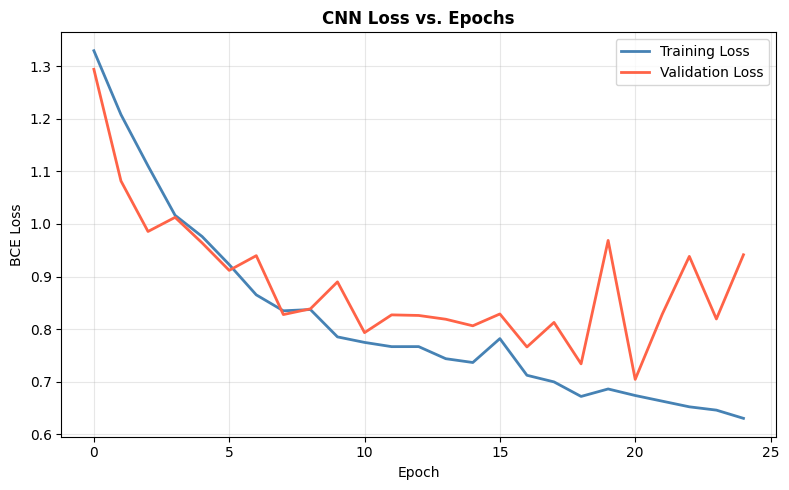

In [49]:
# Plot the training and validation loss curves
plt.figure(figsize=(8, 5))
plt.plot(train_history, label='Training Loss', color='steelblue', linewidth=2)
plt.plot(val_history, label='Validation Loss', color='tomato', linewidth=2)

plt.title('CNN Loss vs. Epochs', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [50]:
# Run it
model, val_loader, device, train_history, val_history = run_training_pipeline(epochs=15)

--- 1. Loading Prebaked Data ---
Split saved → ../../data/models/split_indices.pt  (1188 train / 297 val)
Flattened size: 2048
--- 2. Starting Training on cpu ---
Dataset size: 1188 samples
  Batch 0/19 | Loss: 1.4058
  Batch 10/19 | Loss: 1.1666

Epoch 1/15 | 34.2s | Train Loss: 1.2727 | Val Loss: 1.1929
  flare   : Acc=87.9%  Prec=0.98  Rec=0.75  F1=0.85  TP=104 FP=2 FN=34 TN=157
  transit : Acc=49.2%  Prec=0.33  Rec=0.01  F1=0.01  TP=1 FP=2 FN=149 TN=145
  Batch 0/19 | Loss: 1.1850
  Batch 10/19 | Loss: 1.2489

Epoch 2/15 | 33.4s | Train Loss: 1.1377 | Val Loss: 1.0789
  flare   : Acc=84.2%  Prec=1.00  Rec=0.66  F1=0.79  TP=91 FP=0 FN=47 TN=159
  transit : Acc=48.1%  Prec=0.49  Rec=0.67  F1=0.56  TP=100 FP=104 FN=50 TN=43
  Batch 0/19 | Loss: 0.9281
  Batch 10/19 | Loss: 1.0682

Epoch 3/15 | 33.6s | Train Loss: 1.0307 | Val Loss: 0.9938
  flare   : Acc=87.9%  Prec=1.00  Rec=0.74  F1=0.85  TP=102 FP=0 FN=36 TN=159
  transit : Acc=45.5%  Prec=0.47  Rec=0.57  F1=0.51  TP=85 FP=97 FN=65

In [51]:
# 1. Initialize the empty shell structure
model = LightCurveCNN(input_length=50_000)

# 2. Load the weights dictionary into that structure
state_dict = torch.load("../../data/models/cnn_model.pt", map_location="cpu")
model.load_state_dict(state_dict)

# 3. Put it in evaluation mode
model.eval()

data = torch.load("../../data/models/cnn_dataset.pt", map_location="cpu")
X, y = data['X'], data['y']  # y is (1485, 2): col0=has_flare, col1=has_transit

has_transit = y[:, 1].bool()  # second column
print(f"n_transit: {has_transit.sum()}, n_no_transit: {(~has_transit).sum()}")

with torch.no_grad():
    _, transit_logits = model(X)

probs = transit_logits.sigmoid()
print(f"Transit systems     — mean prob: {probs[has_transit].mean():.3f}  std: {probs[has_transit].std():.3f}")
print(f"No-transit systems  — mean prob: {probs[~has_transit].mean():.3f}  std: {probs[~has_transit].std():.3f}")

Flattened size: 2048
n_transit: 742, n_no_transit: 743
Transit systems     — mean prob: 0.466  std: 0.282
No-transit systems  — mean prob: 0.269  std: 0.088


In [55]:
# ── helpers ──────────────────────────────────────────────────────────────────

_CLASS_MAP = {0: "neither", 1: "flare", 2: "transit", 3: "both"}


def _get_sys_id(sample, df_meta, idx):
    """Resolve system_id from a dataset sample, falling back to df_meta row index."""
    if len(sample) == 5:
        return sample[4]          # (X, y, amp, rad, id)
    if len(sample) == 3:
        return sample[2]          # (X, y, id)
    return df_meta.iloc[idx]["system_id"]


def _encode_true_class(label_y):
    """Map a binary (flare, transit) label tensor to an integer class index."""
    has_flare   = bool(label_y[0].item())
    has_transit = bool(label_y[1].item())
    if has_flare and has_transit:
        return 3
    if has_flare:
        return 1
    if has_transit:
        return 2
    return 0


def _predict_class(flare_prob, transit_prob, flare_thresh, transit_thresh):
    """Threshold two sigmoid probabilities into a named event class."""
    pred_flare   = flare_prob   > flare_thresh
    pred_transit = transit_prob > transit_thresh
    if pred_flare and pred_transit:
        return "both"
    if pred_flare:
        return "flare"
    if pred_transit:
        return "transit"
    return "neither"

In [56]:
def generate_cnn_analysis_df(
    cnn_model,
    dataset,
    df_meta,
    run_device,
    flare_thresh=0.5,
    transit_thresh=0.35,
):
    """Run inference over dataset and return a merged prediction/metadata DataFrame.

    Saves results to ``../../data/models/cnn_full_analysis.csv``.
    """
    cnn_model.eval()
    records = []

    with torch.no_grad():
        for idx, sample in enumerate(dataset):
            inputs = sample[0].unsqueeze(0).to(run_device)
            label  = sample[1]
            sys_id = _get_sys_id(sample, df_meta, idx)

            flare_logits, transit_logits = cnn_model(inputs)

            flare_prob   = flare_logits.sigmoid().item()
            transit_prob = transit_logits.sigmoid().item()

            pred_cls = _predict_class(flare_prob, transit_prob, flare_thresh, transit_thresh)
            true_int  = _encode_true_class(label)

            records.append(
                {
                    "system_id":        sys_id,
                    "true_event_class": _CLASS_MAP[true_int],
                    "pred_event_class": pred_cls,
                    "flare_prob":       flare_prob,
                    "transit_prob":     transit_prob,
                }
            )

    df_preds      = pd.DataFrame(records)
    full_analysis = pd.merge(df_preds, df_meta, on="system_id", how="left")
    full_analysis.to_csv("../../data/models/cnn_full_analysis.csv", index=False)
    return full_analysis


# ── detection-probability plot ────────────────────────────────────────────────

class BinConfig:
    """Grouping parameters for plot_detection_probability."""
    def __init__(self, feature_col, label, bins=10, log_x=False):
        self.feature_col = feature_col
        self.label       = label
        self.bins        = bins
        self.log_x       = log_x

In [57]:
train_loader, val_loader = get_dataloaders("../../data/models/cnn_dataset.pt")
val_dataset   = val_loader.dataset
full_analysis = generate_cnn_analysis_df(
    model, val_dataset, df, "cpu", transit_thresh=0.5
)

Split saved → ../../data/models/split_indices.pt  (1188 train / 297 val)



--- Flare Detection Stats per Bin ---
                           prob  count
bin                                   
(531.879, 758.118]     0.714286     14
(758.118, 993.904]     0.785714     14
(993.904, 1377.333]    0.928571     14
(1377.333, 2019.919]   1.000000     13
(2019.919, 2598.803]   1.000000     14
(2598.803, 4004.205]   1.000000     14
(4004.205, 5731.274]   1.000000     13
(5731.274, 8757.501]   1.000000     14
(8757.501, 13648.34]   1.000000     14
(13648.34, 18480.492]  1.000000     14


/Users/isaacrosenberg/opt/anaconda3/envs/astrobiology/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/isaacrosenberg/opt/anaconda3/envs/astrobiology/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/isaacrosenberg/opt/anaconda3/envs/astrobiology/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding


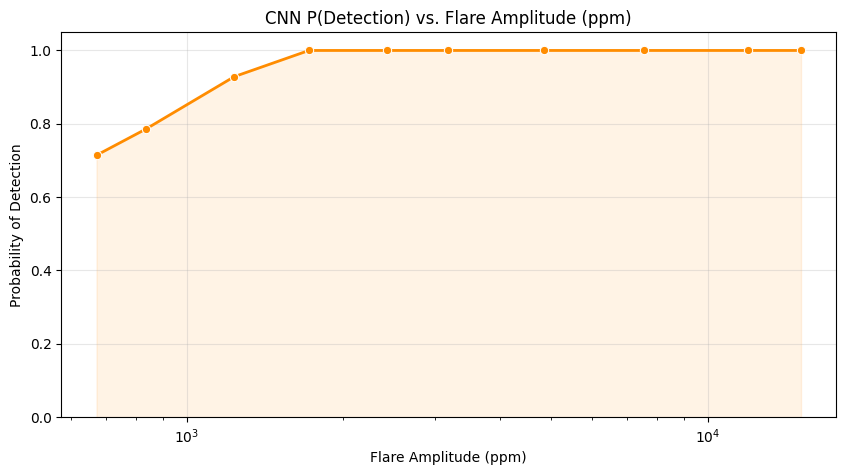

/Users/isaacrosenberg/opt/anaconda3/envs/astrobiology/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/isaacrosenberg/opt/anaconda3/envs/astrobiology/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/Users/isaacrosenberg/opt/anaconda3/envs/astrobiology/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding



--- Transit Detection Stats per Bin ---
                     prob  count
bin                             
(0.208, 0.46]    0.000000     15
(0.46, 0.775]    0.000000     15
(0.775, 0.944]   0.000000     15
(0.944, 1.175]   0.000000     15
(1.175, 1.597]   0.000000     15
(1.597, 1.964]   0.066667     15
(1.964, 2.464]   0.200000     15
(2.464, 3.487]   0.600000     15
(3.487, 5.469]   0.800000     15
(5.469, 24.564]  0.933333     15


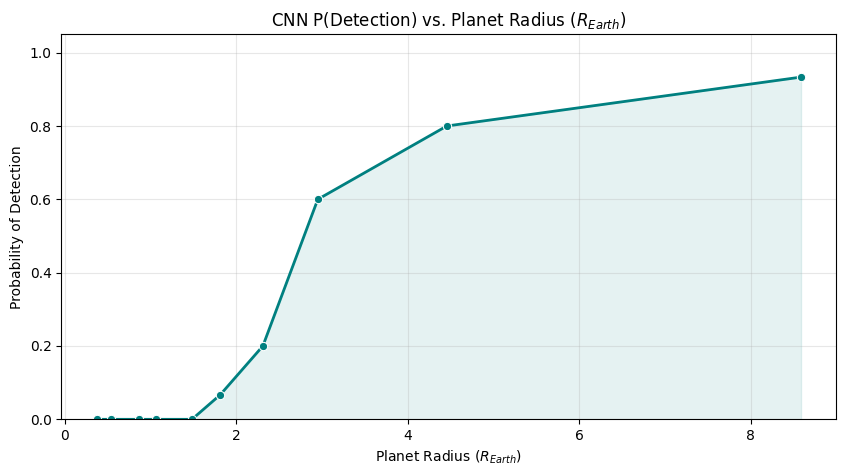

In [58]:
def plot_detection_probability(df_analysis, bin_cfg, target_class="transit"):
    """Plot detection probability vs. a physical feature for a given event class.

    Args:
        df_analysis: DataFrame produced by generate_cnn_analysis_df.
        bin_cfg:     BinConfig instance carrying feature_col, label, bins, log_x.
        target_class: Event class to evaluate ('transit' or 'flare').
    """
    valid_classes = [target_class, "both"]
    subset = df_analysis[df_analysis["true_event_class"].isin(valid_classes)].copy()
    subset = subset.dropna(subset=[bin_cfg.feature_col])

    if subset.empty:
        print(
            f"No {target_class} systems found in this dataset slice "
            f"with valid {bin_cfg.feature_col}."
        )
        return

    subset["is_detected"] = subset["pred_event_class"].isin(valid_classes).astype(int)

    try:
        subset["bin"] = pd.qcut(subset[bin_cfg.feature_col], q=bin_cfg.bins, duplicates="drop")
    except ValueError:
        subset["bin"] = pd.cut(subset[bin_cfg.feature_col], bins=bin_cfg.bins)

    bin_stats = (
        subset.groupby("bin", observed=True)
        .agg(
            prob=(    "is_detected",        "mean"),
            midpoint=(bin_cfg.feature_col,  "median"),
            count=(   "is_detected",        "count"),
        )
        .dropna()
    )

    color = "darkorange" if target_class == "flare" else "teal"
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=bin_stats, x="midpoint", y="prob", marker="o", linewidth=2, color=color)
    plt.fill_between(bin_stats["midpoint"], 0, bin_stats["prob"], alpha=0.1, color=color)

    print(f"\n--- {target_class.capitalize()} Detection Stats per Bin ---")
    print(bin_stats[["prob", "count"]])

    plt.title(f"CNN P(Detection) vs. {bin_cfg.label}")
    plt.xlabel(bin_cfg.label)
    if bin_cfg.log_x:
        plt.xscale("log")
    plt.ylabel("Probability of Detection")
    plt.ylim(0, 1.05)
    plt.grid(alpha=0.3)
    plt.show()
    
plot_detection_probability(
    full_analysis,
    BinConfig("flare_amplitude", "Flare Amplitude (ppm)", bins=10, log_x=True),
    target_class="flare",
)

plot_detection_probability(
    full_analysis,
    BinConfig("transit_radius_earth", r"Planet Radius ($R_{Earth}$)", bins=10, log_x=False),
    target_class="transit",
)